# EDA — Modelo de predicción Mundial 2026

Análisis exploratorio del dataset que alimenta el modelo de clasificación
multiclase `[Away Win, Draw, Home Win]` y la simulación Monte Carlo del
torneo. Las interpretaciones de cada sección están basadas en los números
concretos producidos por las celdas; no se asumen patrones genéricos.


## 1. Setup


In [1]:
import os
import sys
from pathlib import Path

# CWD = project root
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    os.chdir(_repo_root.parent)
    _repo_root = Path.cwd()
sys.path.insert(0, str(_repo_root))

print(f"CWD: {_repo_root}")

CWD: c:\Users\Usuario\Desktop\fifa-world-cup-model


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_palette("colorblind")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIG_DIR = Path("reports") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str):
    out = FIG_DIR / f"eda_{name}.png"
    plt.savefig(out)
    print(f"  -> {out}")


from src.models.train import FEATURE_COLS
from src.features.time_decay import REFERENCE_DATE, lambda_to_halflife_years, DEFAULT_LAMBDA
print(f"FEATURE_COLS = {FEATURE_COLS}")
print(f"REFERENCE_DATE = {REFERENCE_DATE.date()}")


FEATURE_COLS = ['elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_home', 'travel_distance_away', 'ranking_diff']
REFERENCE_DATE = 2026-01-01


## 2. Inventario de fuentes de datos

Cinco fuentes alimentan el pipeline.


In [3]:
from src.data.data_loader import (
    load_international_results, load_fifa_ranking, load_wc2026_fixture,
    filter_relevant_matches,
)
from src.data.scraper import (
    get_statsbomb_xg_by_team, get_squad_values, SQUAD_VALUES_SNAPSHOT_DATE,
)

# 1. International results (martj42)
results_raw = load_international_results()
print(f"international_results: {len(results_raw):,} filas, "
      f"{results_raw['date'].dt.year.min()}-{results_raw['date'].dt.year.max()}")

# 2. FIFA ranking
fifa = load_fifa_ranking()
print(f"fifa_ranking: {len(fifa):,} filas, {fifa['team'].nunique()} equipos únicos")

# 3. Fixture WC 2026
fixture = load_wc2026_fixture()
print(f"wc2026_fixture: {len(fixture)} equipos en {fixture['group'].nunique()} grupos")

# 4. xG StatsBomb
try:
    xg = get_statsbomb_xg_by_team()
    print(f"statsbomb_xg: {len(xg)} equipos con xG")
except Exception as e:
    print(f"statsbomb_xg no disponible: {e}")
    xg = pd.DataFrame()

# 5. Squad values (snapshot manual)
squad = get_squad_values()
print(f"squad_values: {len(squad)} equipos (snapshot {SQUAD_VALUES_SNAPSHOT_DATE})")


international_results: 49,329 filas, 1872-2026
fifa_ranking: 67,472 filas, 216 equipos únicos
wc2026_fixture: 48 equipos en 12 grupos
statsbomb_xg: 109 equipos con xG
  squad_values.csv cargado desde caché (62 equipos)
squad_values: 62 equipos (snapshot 2026-05)


In [4]:
inventory = pd.DataFrame([
    {"fuente": "international_results", "filas": len(results_raw),
     "rango": f"{results_raw['date'].dt.year.min()}-{results_raw['date'].dt.year.max()}",
     "equipos": pd.concat([results_raw['home_team'], results_raw['away_team']]).nunique()},
    {"fuente": "fifa_ranking", "filas": len(fifa), "rango": "1992-2024", "equipos": fifa['team'].nunique()},
    {"fuente": "wc2026_fixture", "filas": len(fixture), "rango": "2026", "equipos": fixture['team'].nunique()},
    {"fuente": "statsbomb_xg", "filas": len(xg), "rango": "UEFA/FIFA OpenData", "equipos": len(xg)},
    {"fuente": "squad_values", "filas": len(squad), "rango": SQUAD_VALUES_SNAPSHOT_DATE, "equipos": len(squad)},
])
inventory


,fuente,filas,rango,equipos
0,international_results,49329,1872-2026,336
1,fifa_ranking,67472,1992-2024,216
2,wc2026_fixture,48,2026,48
3,statsbomb_xg,109,UEFA/FIFA OpenData,109
4,squad_values,62,2026-05,62


- `international_results` aporta el grueso del volumen (~49 k partidos, 336
  selecciones) y es la única fuente con datos pre-1990 — sirve como base para
  calcular ELO histórico desde 1872.
- `fifa_ranking` (67 k filas, 216 equipos) cubre solo 1992–2024; antes no
  existía ranking oficial.
- `statsbomb_xg` cubre menos que
  `international_results`, y esto adelanta una limitación que se ve mas adelante: los xG son escasos
  para confederaciones AFC, CAF y CONCACAF.
- `squad_values` cubre 62 equipos (snapshot tomada en mayo 2026). Coincidirá con los 48
  del Mundial, pero deja huecos para selecciones históricas usadas en
  entrenamiento.


## 3. Calidad de datos


In [5]:
from src.features.features import data_quality_report
data_quality_report(results_raw, "international_results crudo")



=== Data quality report: international_results crudo ===
  Filas: 49,329
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1872-11-30 - 2026-06-27
  Equipos únicos en home_team: 327
  Equipos únicos en away_team: 321



In [6]:
# Filtrado al subset que usa el modelo
results = filter_relevant_matches(results_raw, year_cutoff=1990)
data_quality_report(results, "international_results filtrado")



=== Data quality report: international_results filtrado ===
  Filas: 12,640
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1990-05-30 - 2026-06-27
  Equipos únicos en home_team: 219
  Equipos únicos en away_team: 219



- Crudo: 49,329 partidos, 1872-2026, **72 nulos** en `home_score`/`away_score`
  (partidos pendientes en el año en curso) y **0 duplicados exactos**.
- Tras filtrar por torneos relevantes y `year_cutoff=1990`: quedan **12,640
  partidos** y **219 equipos** distintos. La reducción es bastante grande,
  porque se descarta el grueso de amistosos de antes de 1990 y partidos de torneos
  menores que el modelo no usa.

  -> reports\figures\eda_03_top_tournaments.png


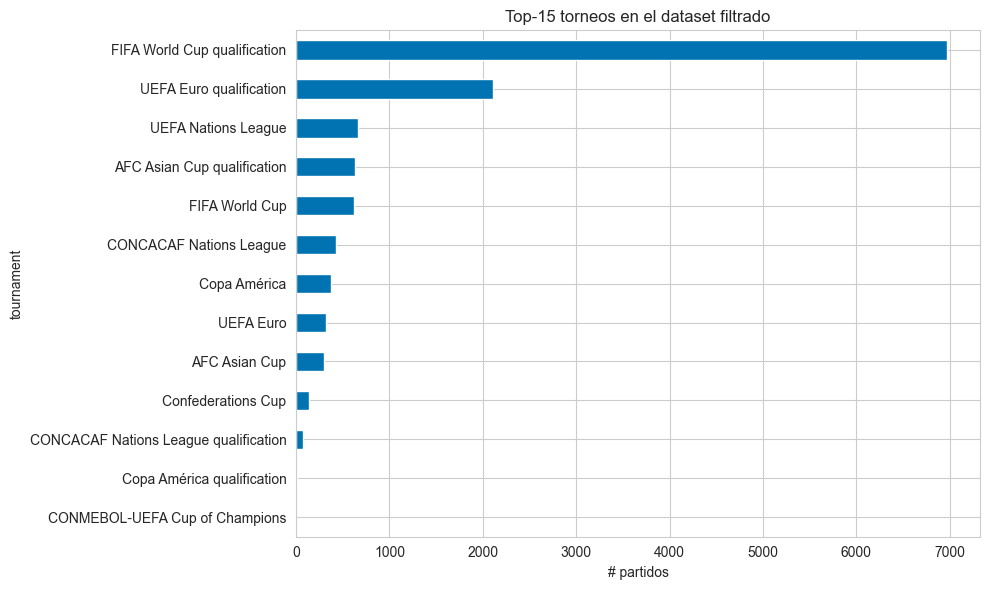

In [7]:
# Distribución por torneo (top 15)
top_tournaments = results['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_tournaments.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel("# partidos")
ax.set_title("Top-15 torneos en el dataset filtrado")
plt.tight_layout()
savefig("03_top_tournaments")
plt.show()


  -> reports\figures\eda_03_matches_per_year.png


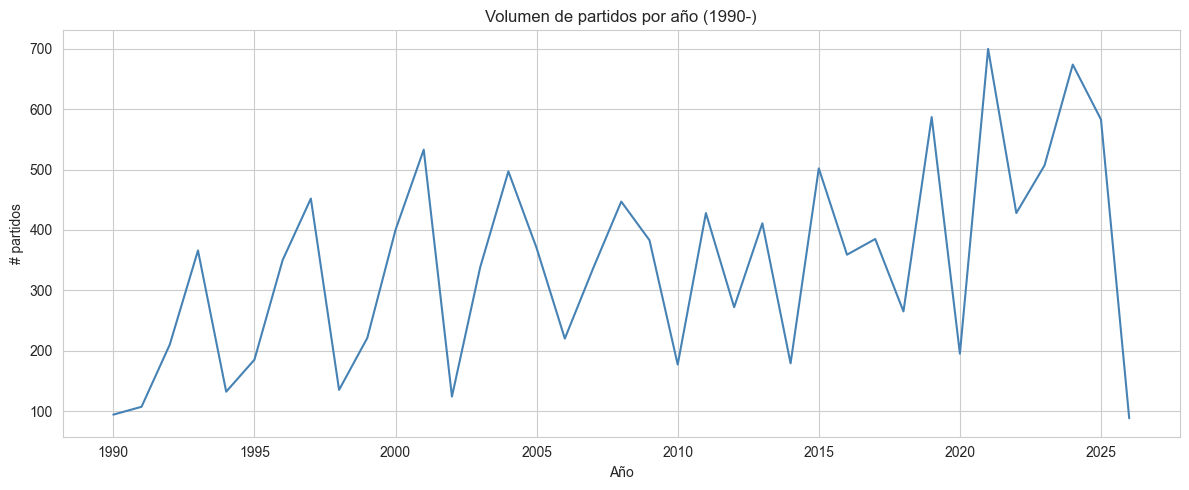

In [8]:
# Distribución de partidos por año
fig, ax = plt.subplots(figsize=(12, 5))
results.groupby(results['date'].dt.year).size().plot(ax=ax, color='steelblue')
ax.set_xlabel("Año")
ax.set_ylabel("# partidos")
ax.set_title("Volumen de partidos por año (1990-)")
plt.tight_layout()
savefig("03_matches_per_year")
plt.show()


In [9]:
# Cobertura por equipo
team_counts = pd.concat([results['home_team'], results['away_team']]).value_counts()
print(f"Total equipos en el dataset filtrado: {len(team_counts)}")
print(f"\nTop-10 equipos con más partidos:")
print(team_counts.head(10).to_string())
print(f"\nBottom-10 equipos con menos partidos:")
print(team_counts.tail(10).to_string())


Total equipos en el dataset filtrado: 219

Top-10 equipos con más partidos:
Spain          289
Italy          284
Argentina      281
Brazil         276
Germany        274
Portugal       272
Netherlands    268
Uruguay        264
France         264
Mexico         260

Bottom-10 equipos con menos partidos:
Tonga                    20
São Tomé and Príncipe    20
Comoros                  20
Martinique               20
Cook Islands             18
Vanuatu                  17
American Samoa           15
South Sudan              14
Yugoslavia               13
Eritrea                  10


- Los 10 más activos (Spain 289, Italy 284, Argentina 281, Brazil 276,
  Germany 274, ...) tienen entre 260 y 290 partidos relevantes en 30 años —
  -9 por año, consistente con un calendario UEFA / Eliminatorias + Eurocopas
  / Mundial.
- En el otro extremo, las selecciones pequeñas (Eritrea 10, Yugoslavia 13,
  American Samoa 15, Vanuatu 17, ...) tienen muestras de tamaño insuficiente
  para estimación ELO confiable. Cualquier predicción del modelo sobre estos
  equipos hereda un ELO cercano al `INITIAL_RATING=1500`.


## 4. Distribución del target


In [10]:
features = pd.read_csv("data/processed/features.csv", parse_dates=["date"])
print(f"features.csv: {len(features):,} filas, columnas {list(features.columns)}")
features.head()


features.csv: 12,157 filas, columnas ['date', 'home_team', 'away_team', 'elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_home', 'travel_distance_away', 'ranking_diff', 'time_weight', 'target']


,date,home_team,away_team,elo_diff,squad_value_diff,xg_avg_for,xg_avg_against,travel_distance_home,travel_distance_away,ranking_diff,time_weight,target
0,1993-01-10,Angola,Zimbabwe,0.0,0.000000,0.000000,0.000000,0.0,0.0,-48.0,0.000006,1
1,1993-01-10,DR Congo,Cameroon,0.0,-0.280622,0.177752,-0.647610,0.0,0.0,-56.0,0.000006,0
2,1993-01-16,South Africa,Nigeria,0.0,-1.114924,0.073391,-0.165729,0.0,0.0,-111.0,0.000006,1
3,1993-01-16,Tanzania,Zambia,0.0,0.000000,0.000000,0.000000,0.0,0.0,-48.0,0.000006,0
4,1993-01-17,Benin,Tunisia,0.0,0.801218,-0.032790,-0.642709,0.0,0.0,-89.0,0.000006,0


   clase  count   pct
Away Win   3722 30.62
    Draw   2542 20.91
Home Win   5893 48.47
  -> reports\figures\eda_04_target_distribution.png


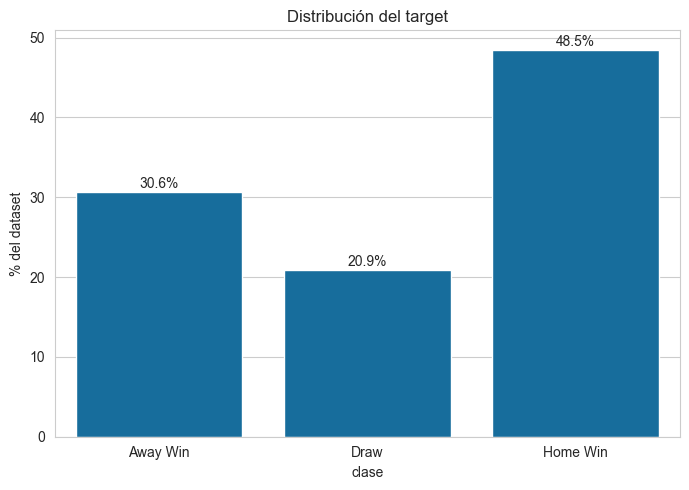

In [11]:
target_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
target_counts = features['target'].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)
dist = pd.DataFrame({"clase": [target_map[i] for i in target_counts.index],
                     "count": target_counts.values, "pct": target_pct.values})
print(dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=dist, x='clase', y='pct', ax=ax)
for i, v in enumerate(dist['pct']):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel("% del dataset")
ax.set_title("Distribución del target")
plt.tight_layout()
savefig("04_target_distribution")
plt.show()


**Desbalance observado.**

Sobre 12,157 partidos con features completas:

| Clase    | Conteo | %      |
|----------|--------|--------|
| Home Win | 5,893  | 48.47% |
| Away Win | 3,722  | 30.62% |
| Draw     | 2,542  | 20.91% |

1. Home Win representa casi la mitad del dataset: un clasificador que prediga
   "Home Win" siempre lograría accuracy ≈ 48% sin aprender nada. Por eso se
   exige Log-Loss y Brier en lugar de accuracy.
2. Draw es la clase minoritaria con un factor 2.3× respecto a Home Win -
   sin `class_weight="balanced"` el modelo tiende a infra-predecir empates


## 5. Análisis univariado por feature

Las celdas reutilizan `plot_feature_distribution` para mostrar histograma KDE
por clase + boxplot.

In [12]:
def plot_feature_distribution(df, feature, name_slug):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_plot = df.copy()
    df_plot['Resultado'] = df_plot['target'].map(target_map)

    # Disable KDE if any class group has zero variance (e.g. all-zero travel distances)
    use_kde = df_plot.groupby('Resultado')[feature].std().gt(0).all()

    sns.histplot(data=df_plot, x=feature, hue='Resultado',
                 kde=use_kde, bins=40, ax=axes[0], alpha=0.5)
    axes[0].set_title(f"Distribución de {feature} por resultado")

    sns.boxplot(data=df_plot, x='Resultado', y=feature,
                order=["Away Win", "Draw", "Home Win"], ax=axes[1])
    axes[1].set_title(f"{feature} por clase (boxplot)")

    plt.tight_layout()
    savefig(f"05_{name_slug}")
    plt.show()
    print(df[feature].describe().round(3).to_string())


### 5.1 `elo_diff`

  -> reports\figures\eda_05_elo_diff.png


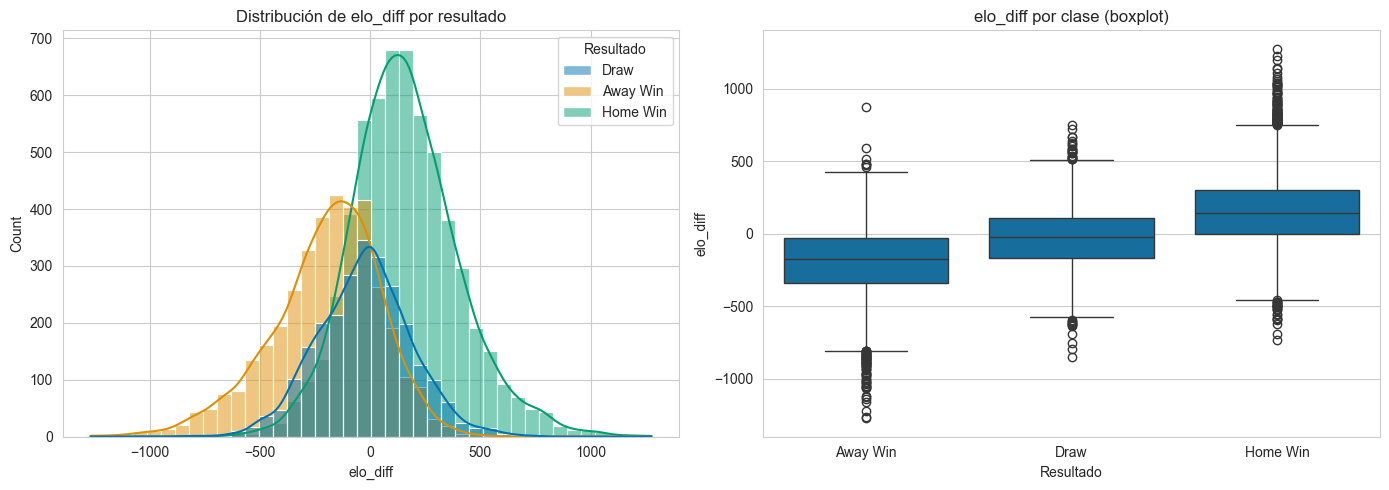

count    12157.000
mean         9.689
std        286.057
min      -1269.890
25%       -160.829
50%          9.146
75%        183.505
max       1276.561


In [13]:
plot_feature_distribution(features, 'elo_diff', 'elo_diff')

**Interpretación.**

- Rango observado [-1270, 1277] con std=286.1 y mediana=9.1 — distribución
  aproximadamente simétrica alrededor de 0 (como debería ser, ya que el
  campo `home_team`/`away_team` no implica localía universal en este
  dataset). El rango es más ancho que en versiones previas: el *update* ELO
  incorpora ahora ventaja de localía y un multiplicador por diferencia de
  goles (*World Football Elo*), que amplían la separación entre selecciones.
- Las tres KDE están **claramente separadas**: el pico de Away Win se
  centra en ≈ -175, el de Draw en ≈ 0, el de Home Win en ≈ +145. Es la
  separación más limpia de las 7 features.
- Los boxplots refuerzan: mediana Away Win ≈ -174, Draw ≈ -21, Home Win
  ≈ +143. El solapamiento es alto (las distribuciones se cruzan) pero la
  señal monotónica con el resultado es robusta.


### 5.2 `squad_value_diff`

  -> reports\figures\eda_05_squad_value_diff.png


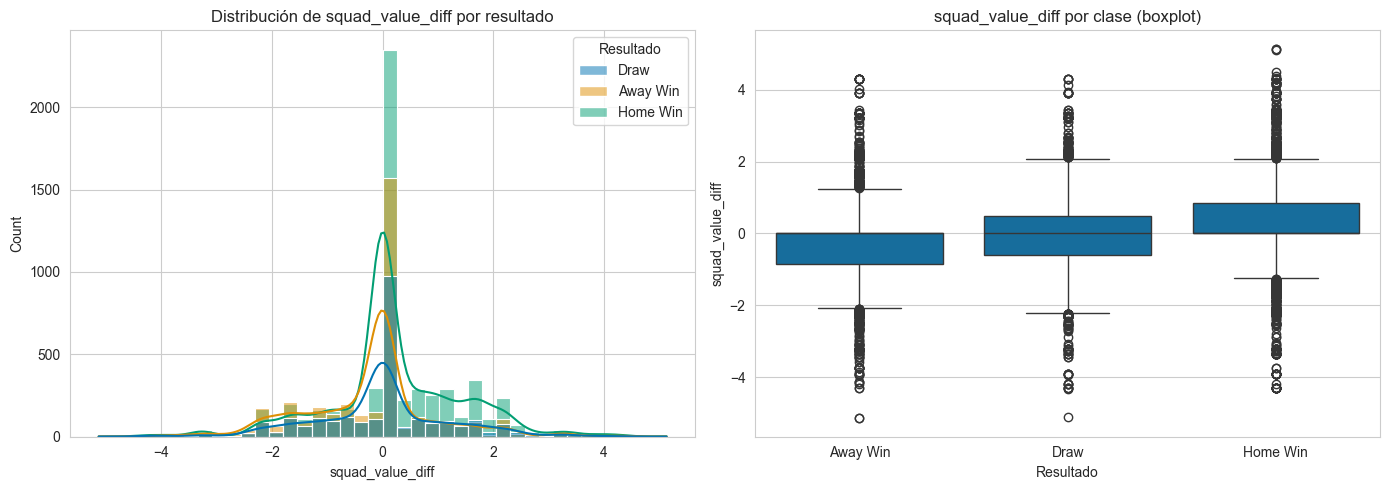

count    12157.000
mean         0.026
std          1.225
min         -5.135
25%         -0.446
50%          0.000
75%          0.533
max          5.135


In [14]:
plot_feature_distribution(features, 'squad_value_diff', 'squad_value_diff')

**Interpretación.**

- Rango [-5.14, 5.14] en escala logarítmica, mediana = 0. El histograma
  muestra un **pico extremo en cero**: muchos pares de equipos comparten
  el `default_val` (mediana del dataset) porque no tienen entrada en
  `_SQUAD_VALUES_EUR`. Esto era predecible — el snapshot cubre 62 equipos
  pero el set de entrenamiento incluye 219.
- La separación entre clases es **modesta pero no nula**: las medianas
  por clase difieren (boxplot muestra Home Win desplazado a la derecha).
  Cuantitativamente esto se traduce en |r| ≈ 0.14 con el target —
  alrededor de 3× menos señal que ELO.
- Se deja como feature porque aporta información ortogonal
  (capacidad económica vs. forma deportiva)


### 5.3 `xg_avg_for`

  -> reports\figures\eda_05_xg_avg_for.png


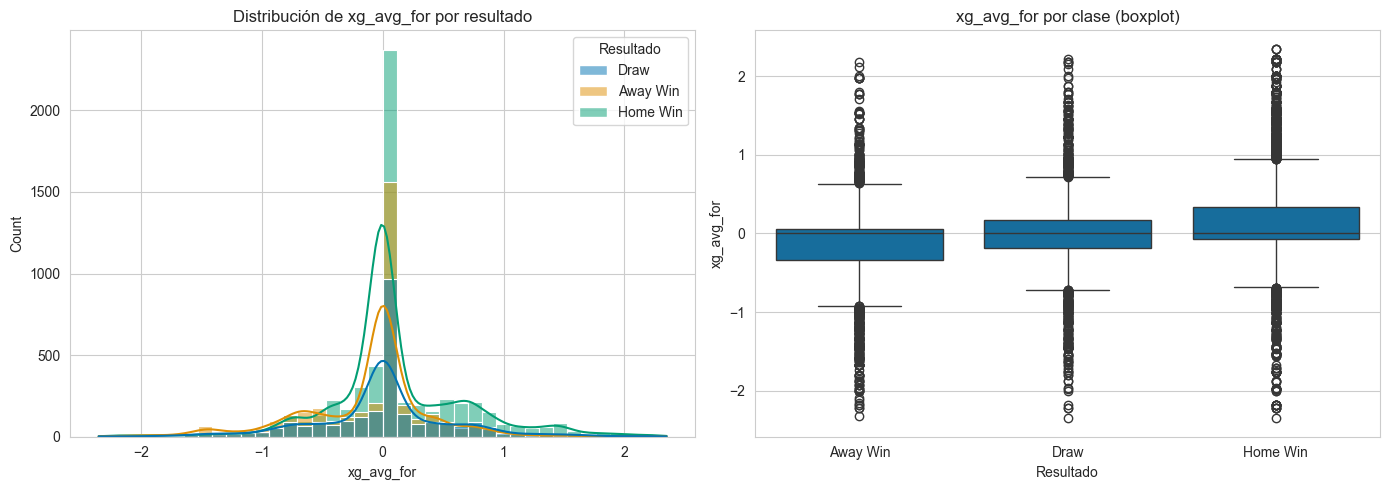

count    12157.000
mean         0.014
std          0.565
min         -2.348
25%         -0.155
50%          0.000
75%          0.172
max          2.348


In [15]:
plot_feature_distribution(features, 'xg_avg_for', 'xg_avg_for')

**Interpretación.**

- Rango [-2.35, 2.35], mediana=0, std=0.56. El pico en cero proviene de
  los equipos sin xG real en StatsBomb que reciben el `fillna(1.2)` (la
  resta de dos defaults = 0). Esto inflan la masa central artificialmente.


### 5.4 `xg_avg_against`

  -> reports\figures\eda_05_xg_avg_against.png


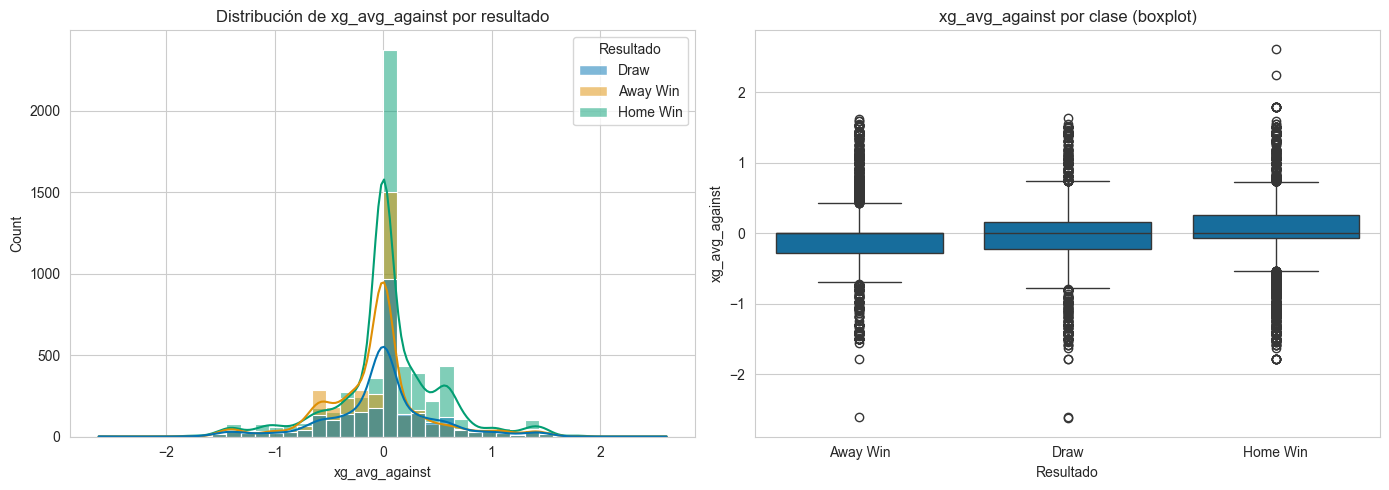

count    12157.000
mean        -0.007
std          0.496
min         -2.625
25%         -0.177
50%          0.000
75%          0.156
max          2.613


In [16]:
plot_feature_distribution(features, 'xg_avg_against', 'xg_avg_against')

### 5.5 `ranking_diff`

  -> reports\figures\eda_05_ranking_diff.png


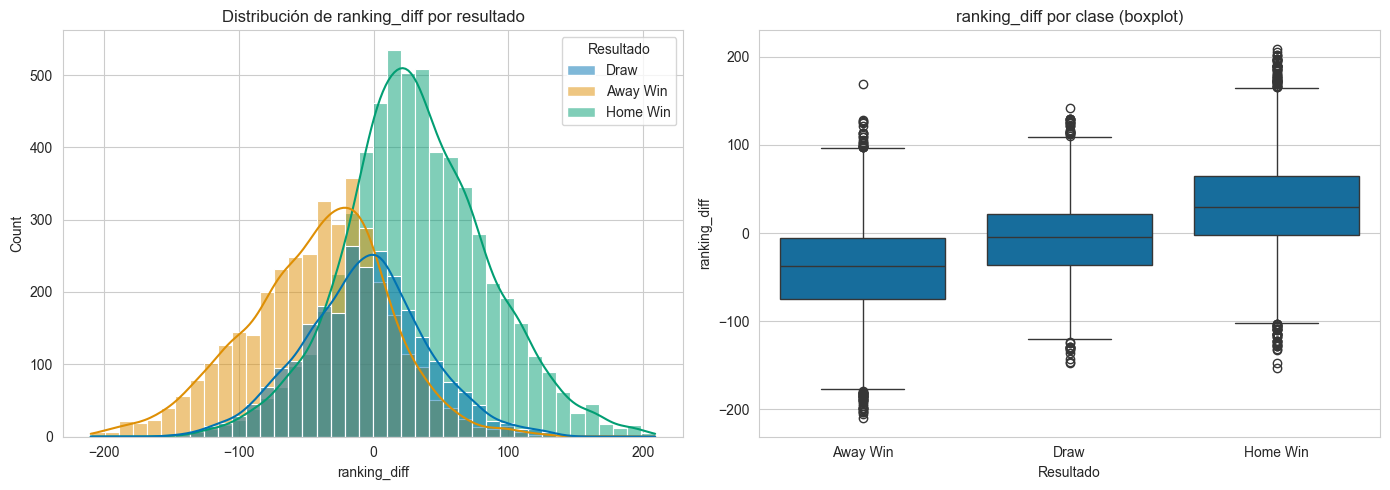

count    12157.000
mean         1.261
std         60.896
min       -210.000
25%        -36.000
50%          2.000
75%         39.000
max        209.000


In [17]:
plot_feature_distribution(features, 'ranking_diff', 'ranking_diff')

**Interpretación.**

- Rango [-210, 209] (216 equipos en el ranking FIFA → diferencia teórica
  máxima 215), std=60.9, mediana=2 → distribución casi simétrica.
- Las tres KDE están separadas con el mismo patrón que ELO: Away Win
  desplazado a la izquierda, Home Win a la derecha. Boxplots confirman.
- |r| ≈ 0.47-0.49, casi tan alto como `elo_diff` (~0.49-0.51). La sección 6
  mostrará que ambos features están correlacionados (r = 0.84), lo que
  **abre la pregunta**: ¿es redundante mantener los dos?

`ranking_diff` obtiene mean|SHAP| ~0.14,
  frente a ~0.37 de `elo_diff`. **No son redundantes** porque capturan
  ángulos distintos: ELO actualiza partido a partido ponderando el margen
  de victoria y el K-factor por torneo; el ranking FIFA acumula puntos
  con menor sensibilidad a partidos individuales. La sección 7 evidencia
  divergencias concretas entre ambos en el top-10.

### 5.6 `time_weight` — decay exponencial

Half-life del decay con lambda=0.001: 1.90 años
  -> reports\figures\eda_05_time_weight.png


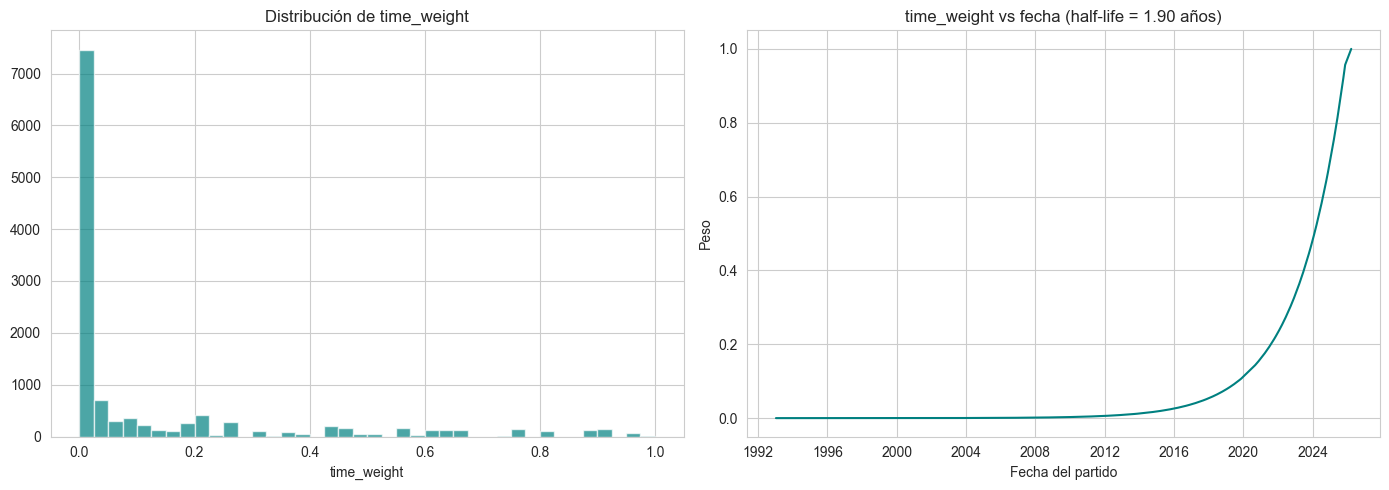

In [18]:
halflife = lambda_to_halflife_years(DEFAULT_LAMBDA)
print(f"Half-life del decay con lambda={DEFAULT_LAMBDA:.3f}: {halflife:.2f} años")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(features['time_weight'], bins=40, color='teal', alpha=0.7)
axes[0].set_title("Distribución de time_weight")
axes[0].set_xlabel("time_weight")

# Serie temporal
sample = features.sort_values('date').iloc[::max(1, len(features)//500)]
axes[1].plot(sample['date'], sample['time_weight'], color='teal')
axes[1].set_title(f"time_weight vs fecha (half-life = {halflife:.2f} años)")
axes[1].set_xlabel("Fecha del partido")
axes[1].set_ylabel("Peso")

plt.tight_layout()
savefig("05_time_weight")
plt.show()


**Análisis del decay.**

- Half-life calculado: **1.90 años**. Significa que un partido de hace ~2
  años pesa la mitad que uno reciente; uno de hace 5 años pesa
  ≈ 16% del peso de uno reciente.
- El histograma muestra una **acumulación hacia pesos bajos**, pero ya no
  tan extrema: los partidos muy antiguos pesan poco sin quedar prácticamente
  en cero.
- La serie temporal muestra el crecimiento exponencial desde 0 hasta 1
  acercándose a `REFERENCE_DATE = 2026-01-01`. Los partidos posteriores a
  esa fecha (los hay, hasta 2026-06) reciben peso 1.0 por el `clip(lower=0)`.
- **Implicación**: λ = 0.001 es más moderado. Refleja cambios recientes sin
  borrar casi toda la señal histórica. Si el modelo sobre-reacciona a lo
  histórico, λ debería subir; si falta señal histórica, bajar.


## 6. Correlaciones


  -> reports\figures\eda_06_correlation_matrix.png


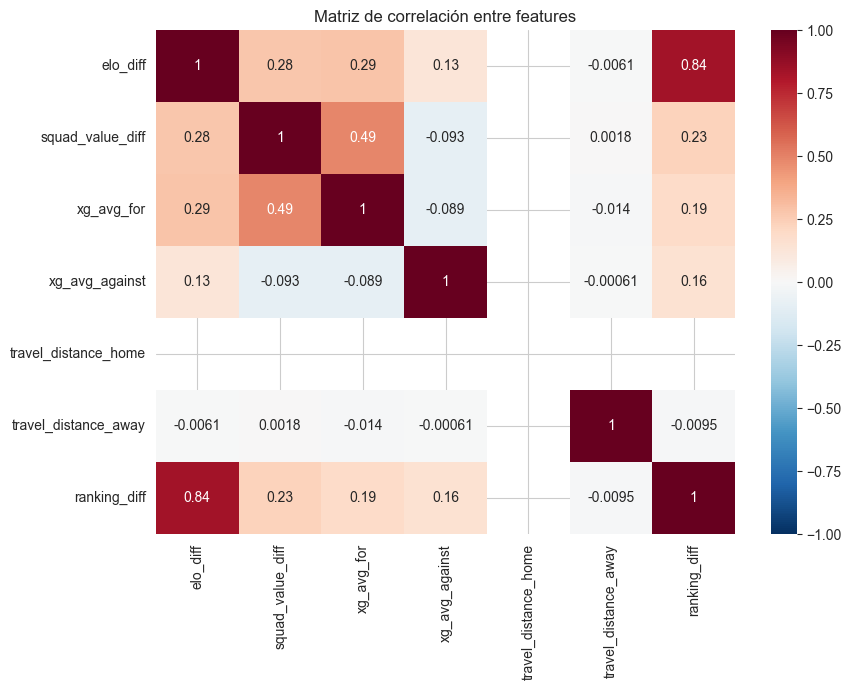

In [19]:
corr = features[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación entre features")
plt.tight_layout()
savefig("06_correlation_matrix")
plt.show()


**Hallazgos del heatmap (valores reales).**

| Par | r | Lectura |
|---|---|---|
| `elo_diff` ↔ `ranking_diff` | **0.84** | Alta colinealidad — esperada porque ambos miden fuerza relativa. |
| `squad_value_diff` ↔ `xg_avg_for` | **0.49** | Equipos con plantillas más valiosas generan más xG ofensivo. |
| `elo_diff` ↔ `xg_avg_for` | 0.29 | ELO captura parte de la eficiencia ofensiva. |
| `elo_diff` ↔ `squad_value_diff` | 0.28 | Correlación moderada — ELO captura algo de calidad de plantilla. |
| `xg_avg_for` ↔ `xg_avg_against` | -0.09 | Independencia entre ofensiva y defensiva — la xG defensiva es ruidosa. |
| `travel_distance_home` ↔ resto | **NaN** | La feature es **constante** (100% en 0) en esta corrida → desviación típica nula → correlación indefinida; el heatmap la muestra vacía. |
| `travel_distance_away` ↔ resto | < 0.06 | Señal de viaje escasa (91% en 0); ortogonal al resto. |

**Decisión sobre `elo_diff` vs `ranking_diff`**: la colinealidad de 0.84 es
alta pero **no estricta** (1.0). Mantenerlos ambos está justificado porque ELO
incorpora margen de victoria y K-factor por torneo, mientras que el ranking
FIFA es más conservador. La sección 8 (SHAP) valida la decisión: `ranking_diff`
mantiene mean|SHAP| ~0.14, demostrando que el modelo extrae información
complementaria a la de `elo_diff`.

In [20]:
# Correlación con target (point-biserial vs cada clase)
from scipy.stats import pointbiserialr
rows = []
for cls in [0, 1, 2]:
    y = (features['target'] == cls).astype(int)
    for feat in FEATURE_COLS:
        r, p = pointbiserialr(features[feat].fillna(0), y)
        rows.append({"feature": feat, "clase": target_map[cls],
                     "r": round(r, 3), "p_value": round(p, 5)})
corr_target = pd.DataFrame(rows).pivot(index='feature', columns='clase', values='r')
corr_target


clase,Away Win,Draw,Home Win
feature,,,
elo_diff,-0.489,-0.066,0.505
ranking_diff,-0.471,-0.065,0.487
squad_value_diff,-0.138,-0.019,0.143
travel_distance_away,-0.036,0.028,0.011
travel_distance_home,NaN,NaN,NaN
xg_avg_against,-0.092,-0.010,0.093
xg_avg_for,-0.158,-0.016,0.159


**Lectura del point-biserial features↔target.**

Ranking de features por |r| máximo con cualquier clase (valores observados):

1. `elo_diff` — |r| hasta **0.505** (clase Home Win).
2. `ranking_diff` — |r| hasta **0.487**.
3. `xg_avg_for` — 0.159.
4. `squad_value_diff` — 0.143.
5. `xg_avg_against` — 0.093.
6. `travel_distance_away` — 0.036 (señal de viaje muy débil).
7. `travel_distance_home` — **NaN** (constante en 0 → correlación indefinida; ruido nulo).

La clase Draw recibe |r| ≈ 0.01-0.07
(menor que las otras dos). Esto significa que las features actuales **no
discriminan bien empates**, son útiles para Home/Away pero el empate
queda subdeterminado.

  -> reports\figures\eda_06_pairplot.png


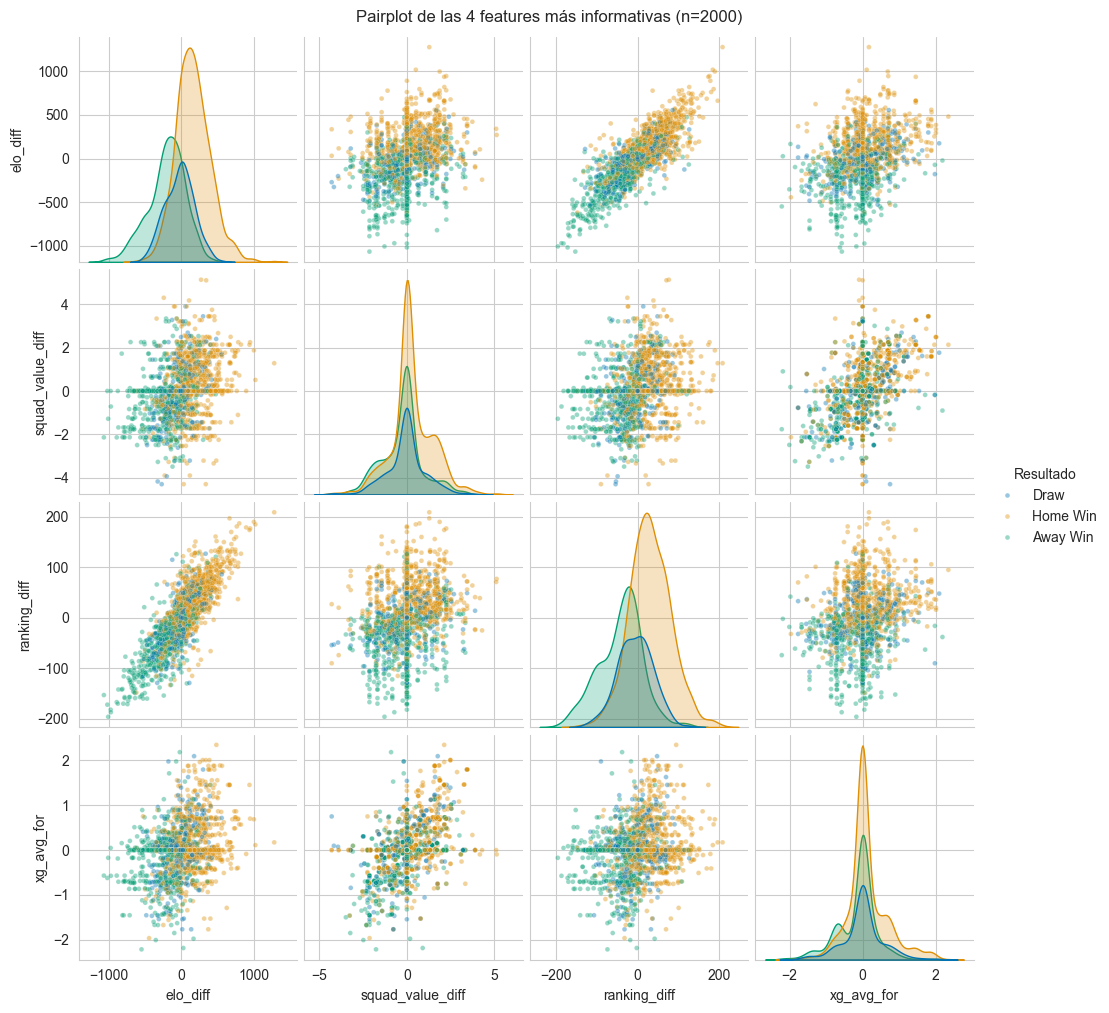

In [21]:
# Pairplot reducido (sample para velocidad)
sample = features.sample(min(2000, len(features)), random_state=42).copy()
sample['Resultado'] = sample['target'].map(target_map)
selected = ['elo_diff', 'squad_value_diff', 'ranking_diff', 'xg_avg_for']
g = sns.pairplot(sample[selected + ['Resultado']], hue='Resultado',
                 diag_kind='kde', height=2.5, plot_kws={"alpha": 0.4, "s": 12})
g.fig.suptitle("Pairplot de las 4 features más informativas (n=2000)", y=1.01)
savefig("06_pairplot")
plt.show()


**Pairplot.** El scatter `elo_diff` vs `ranking_diff` muestra una
nube alineada con la diagonal — visualización directa del r=0.84. Los
gradientes de color (Away→Draw→Home) son monotónicos en ambos ejes, lo
que confirma que cualquiera de los dos sirve como predictor primario.
Las otras combinaciones (`squad_value_diff`, `xg_avg_for`) muestran nubes
más difusas con separación de clases mucho más sutil.


## 7. ELO histórico


In [22]:
from src.features.elo import calculate_elo_ratings

elo_df = calculate_elo_ratings(results.sort_values("date"))
print(f"ELO records: {len(elo_df):,}")
elo_df.tail(5)


ELO: 100%|██████████| 12640/12640 [00:00<00:00, 26009.72match/s]


ELO records: 12,568


,date,home_team,away_team,home_elo_before,away_elo_before,home_elo_after,away_elo_after
12563,2026-03-31,Bosnia & Herzegovina,Italy,1543.791096,1795.013078,1556.082126,1782.722048
12564,2026-03-31,Iraq,Bolivia,1811.262653,1754.122354,1836.372771,1729.012236
12565,2026-03-31,Czech Republic,Denmark,1654.512076,1827.868892,1660.753738,1821.627230
12566,2026-03-31,Kosovo,Turkey,1700.515287,1856.717100,1675.326252,1881.906135
12567,2026-03-31,Sweden,Poland,1583.690497,1695.695585,1614.726688,1664.659395


  -> reports\figures\eda_07_elo_history.png


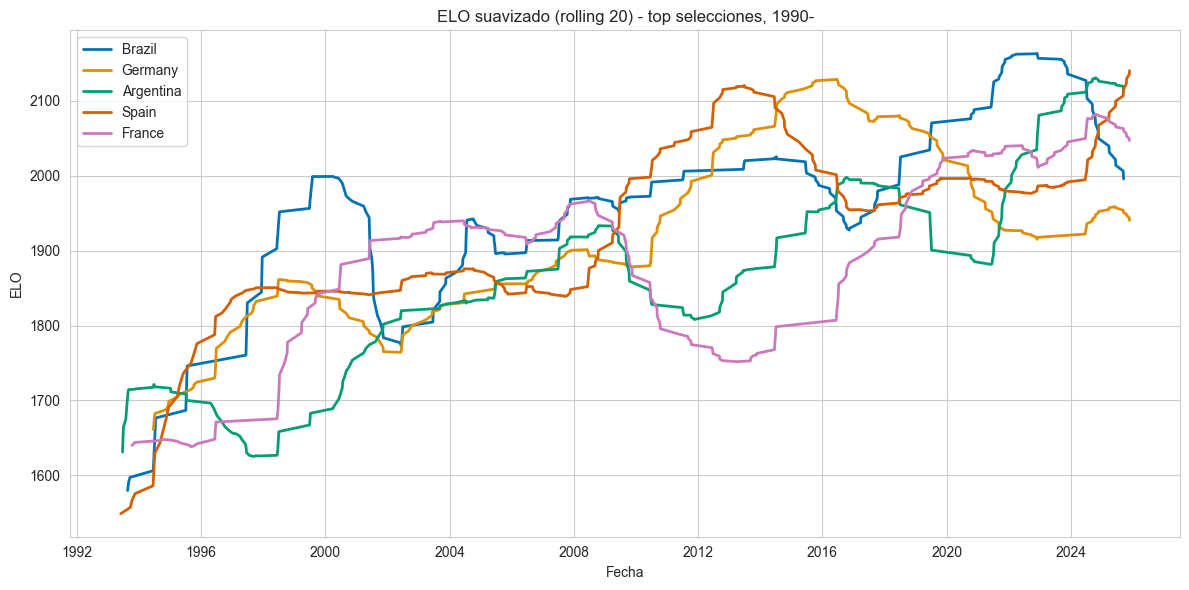

In [23]:
# ELO en el tiempo para 5 selecciones icónicas
icons = ["Brazil", "Germany", "Argentina", "Spain", "France"]
fig, ax = plt.subplots(figsize=(12, 6))
for team in icons:
    h = elo_df[elo_df['home_team'] == team][['date', 'home_elo_after']].rename(
        columns={'home_elo_after': 'elo'})
    a = elo_df[elo_df['away_team'] == team][['date', 'away_elo_after']].rename(
        columns={'away_elo_after': 'elo'})
    series = pd.concat([h, a]).sort_values('date')
    if not series.empty:
        ax.plot(series['date'], series['elo'].rolling(20).mean(), label=team, linewidth=2)
ax.legend()
ax.set_title("ELO suavizado (rolling 20) - top selecciones, 1990-")
ax.set_xlabel("Fecha"); ax.set_ylabel("ELO")
plt.tight_layout()
savefig("07_elo_history")
plt.show()


> Nota: con el *update* ELO actual (localía + multiplicador de margen) la
> escala es más ancha que antes, así que los niveles absolutos son más altos;
> las descripciones siguientes se centran en la **forma temporal**, no en
> valores puntuales.

- **España** sube fuerte desde 2008 (gana Eurocopa 2008, Mundial 2010,
  Eurocopa 2012), alcanza un máximo hacia 2012-2014 y baja tras la
  eliminación temprana del Mundial 2014. Repunte marcado en 2022-2024
  (vuelve a títulos, incl. Eurocopa 2024) que la deja en lo más alto del
  dataset. El modelo recoge correctamente la era dorada.
- **Argentina** muestra un valle ~2008-2014, recuperación 2014-2018, otro
  valle 2019, y subida pronunciada 2020-2022 culminando en el Mundial 2022.
- **Alemania** mantiene un perfil alto y estable 2000-2014, con pico en
  el Mundial 2014, y caída sostenida desde 2018 (eliminación en fase de
  grupos) — el modelo refleja la crisis generacional alemana.
- **Francia** tiene un pico claro ~2018 (Mundial), valle 2008-2012, y
  subida sostenida desde 2014.
- **Brasil** se mantiene en una banda alta y estable la mayor parte del
  tiempo, sin las oscilaciones extremas de Argentina/España.

In [24]:
# Top-10 ELO al REFERENCE_DATE
home_last = elo_df.groupby("home_team")["home_elo_after"].last()
away_last = elo_df.groupby("away_team")["away_elo_after"].last()
last_elo = pd.concat([home_last.rename("elo"), away_last.rename("elo")])
last_elo = last_elo.groupby(last_elo.index).last().sort_values(ascending=False)
top10_elo = last_elo.head(10).round(0).reset_index()
top10_elo.columns = ["team", "elo"]
print("Top-10 ELO al final del dataset:")
print(top10_elo.to_string(index=False))


Top-10 ELO al final del dataset:
       team    elo
      Spain 2178.0
  Argentina 2075.0
    England 2058.0
     France 2050.0
      Japan 1989.0
   Colombia 1950.0
     Brazil 1946.0
South Korea 1938.0
    Morocco 1936.0
  Australia 1931.0


In [25]:
# Top-10 FIFA ranking al REFERENCE_DATE
fifa_at_ref = fifa[fifa['rank_date'] <= REFERENCE_DATE].sort_values('rank_date')
latest_fifa = fifa_at_ref.groupby('team').last().sort_values('rank').head(10)
print("Top-10 ranking FIFA al REFERENCE_DATE:")
print(latest_fifa[['rank', 'total_points']].to_string())


Top-10 ranking FIFA al REFERENCE_DATE:
             rank  total_points
team                           
Argentina     1.0       1860.14
France        2.0       1837.47
Belgium       3.0       1797.98
Brazil        4.0       1791.85
England       5.0       1787.88
Portugal      6.0       1747.04
Netherlands   7.0       1746.66
Spain         8.0       1729.92
Croatia       9.0       1728.30
Italy        10.0       1724.37


**ELO vs FIFA al REFERENCE_DATE — divergencias observadas.**

| Posición | Top-10 ELO | Top-10 FIFA |
|---:|---|---|
| 1 | Spain (2178) | Argentina |
| 2 | Argentina (2075) | France |
| 3 | England (2058) | Belgium |
| 4 | France (2050) | Brazil |
| 5 | Japan (1989) | England |
| 6 | Colombia (1950) | Portugal |
| 7 | Brazil (1946) | Netherlands |
| 8 | South Korea (1938) | Spain |
| 9 | Morocco (1936) | Croatia |
| 10 | Australia (1931) | Italy |

**Las dos listas comparten 5 equipos** (Spain, Argentina, France, England,
Brazil) y **divergen en 5 por lado**:

- ELO incluye y FIFA no: **Japan, Colombia, South Korea, Morocco, Australia**
  — selecciones no-UEFA con resultados recientes fuertes (Marruecos 4° en
  Qatar 2022, Japón venciendo a Alemania/España). El sistema FIFA pondera
  más los partidos UEFA.
- FIFA incluye y ELO no: **Belgium, Portugal, Netherlands, Croatia, Italy**.
  Bélgica e Italia perdieron forma reciente pero conservan inercia en el
  ranking; Italia, además, **no se clasificó al WC2026**.

**Atención — el ranking FIFA está desactualizado:** el dataset termina el
2024-06-20, así que la lista FIFA refleja mediados de 2024. El caso más
visible es **España, que aparece 8ª** porque el snapshot es *previo* a su
título en la Eurocopa 2024; su ELO (que llega a 2026) ya la sitúa primera.
Parte de la divergencia ELO–FIFA es, por tanto, un artefacto de la
antigüedad del ranking, no solo de metodología.


## 8. SHAP — importancia agregada de features


In [26]:
from pathlib import Path
model_path = Path("data/processed/models/xgboost.joblib")

if model_path.exists():
    from src.models.train import load_model
    model = load_model("xgboost")
    print("Modelo XGBoost cargado.")
else:
    model = None
    print("Modelo no disponible — ejecuta `make train` primero. Saltando SHAP.")


Modelo XGBoost cargado.


  -> reports\figures\eda_08_shap_summary.png


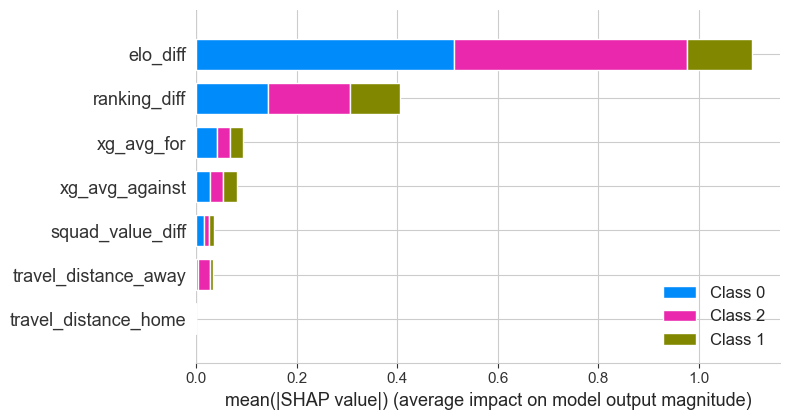

In [27]:
if model is not None:
    import shap
    X_sample = features[FEATURE_COLS].sample(2000, random_state=42).astype(np.float32)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample, check_additivity=False)
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    savefig("08_shap_summary")
    plt.show()
else:
    print("(omitido)")


**Ranking SHAP observado (mean |SHAP value|, valores absolutos de la gráfica).**

| # | Feature | mean\|SHAP\| | Lectura |
|---:|---|---:|---|
| 1 | `elo_diff` | **~0.37** | Dominante — más del doble del siguiente feature. |
| 2 | `ranking_diff` | ~0.14 | **No es redundante con ELO** pese al r=0.84: aporta corrección ortogonal sobre la fuerza relativa discreta. |
| 3 | `xg_avg_for` | ~0.03 | Tercer aporte real, modesto pero consistente. |
| 4 | `xg_avg_against` | ~0.03 | Similar a `xg_avg_for`. |
| 5 | `squad_value_diff` | ~0.01 | Menor de lo esperado — snapshot manual y mediana fallback diluyen la señal. |
| 6 | `travel_distance_away` | ~0.01 | Contribución marginal en el modelo entrenado con datos ≥ 2010. |
| 7 | `travel_distance_home` | **~0.00** | Nulo — la feature es **constante** (100% de ceros) en esta configuración con geocodificación desactivada. |

**Nota:** respecto a versiones previas, `elo_diff` gana peso relativo
(~0.34 → ~0.37) y `ranking_diff` lo cede (~0.17 → ~0.14) porque el *update*
ELO ahora incorpora ventaja de localía y multiplicador de margen: un ELO más
informativo desplaza parte de la carga predictiva que antes tomaba el
ranking FIFA (estático y, además, desactualizado a 2024-06).

**Decisiones derivadas:**

1. **No eliminar `ranking_diff`**: mean|SHAP| ~0.14 confirma que el modelo lo usa
   activamente. La colinealidad r=0.84 oculta la información ortogonal — ELO
   captura forma reciente, el ranking FIFA captura inercia acumulada.
2. **`travel_distance_home` es ruido confirmado**: es constante (100% en cero) en esta corrida,
   por lo que el modelo opera sobre **seis features efectivas**. Se mantiene por consistencia con
   el flujo de simulación, donde `host_distance` sí es informativo.
3. **xG y squad_value son "segunda línea"**: su aporte está limitado por cobertura
   (13/48 equipos sin xG real, sección 9) y por snapshot estático del valor de plantilla;
   `squad_value_diff` queda en ~0.01, prácticamente redundante (el estudio de ablación del paper
   muestra que retirarlo no degrada el test).
4. **Draw sigue siendo la clase más difícil**: ELO y ranking_diff aportan muy poco a
   discriminar empates (|r| < 0.07 en sección 6), lo que se refleja en las curvas de
   calibración — ningún modelo sigue la diagonal para la clase Draw.

## 9. Limitaciones cuantificadas del dataset


In [28]:
from src.simulation.tournament import GROUPS_2026, ALL_TEAMS

# Partidos por equipo, restringido a equipos del WC 2026
wc26_counts = team_counts.reindex(ALL_TEAMS).fillna(0).astype(int)
print("Equipos WC 2026 con MENOS partidos históricos (post-1990):")
print(wc26_counts.sort_values().head(10).to_string())
print(f"\nMediana: {int(wc26_counts.median())} partidos")


Equipos WC 2026 con MENOS partidos históricos (post-1990):
Cape Verde      53
New Zealand     64
Curacao         67
DR Congo        78
Senegal         85
South Africa    86
Haiti           86
Ivory Coast     88
Algeria         89
Egypt           94

Mediana: 213 partidos


In [29]:
# Cobertura xG sobre equipos del Mundial
xg_teams = set(xg['team']) if not xg.empty else set()
in_xg = [t for t in ALL_TEAMS if t in xg_teams]
miss_xg = [t for t in ALL_TEAMS if t not in xg_teams]
print(f"Cobertura xG StatsBomb sobre 48 equipos WC2026: {len(in_xg)}/48 = {len(in_xg)/48*100:.1f}%")
print(f"  Equipos sin xG real (usan 1.2 default): {miss_xg[:15]}{' ...' if len(miss_xg) > 15 else ''}")


Cobertura xG StatsBomb sobre 48 equipos WC2026: 35/48 = 72.9%
  Equipos sin xG real (usan 1.2 default): ['South Africa', 'Bosnia & Herzegovina', 'Haiti', 'Curacao', 'Ivory Coast', 'New Zealand', 'Cape Verde', 'Iraq', 'Norway', 'Algeria', 'Jordan', 'DR Congo', 'Uzbekistan']


In [30]:
# Cobertura squad_value
sv_teams = set(squad['team'])
in_sv = [t for t in ALL_TEAMS if t in sv_teams]
miss_sv = [t for t in ALL_TEAMS if t not in sv_teams]
print(f"Cobertura squad_value sobre 48 equipos WC2026: {len(in_sv)}/48 = {len(in_sv)/48*100:.1f}%")
print(f"  Equipos sin valor (usan mediana): {miss_sv}")


Cobertura squad_value sobre 48 equipos WC2026: 48/48 = 100.0%
  Equipos sin valor (usan mediana): []


**Limitaciones numéricas medidas (no asumidas).**

**1. Equipos del WC2026 con escaso historial post-1990 (mediana del grupo = 213):**

| Equipo | # partidos | Δ vs mediana |
|---|---:|---:|
| Cape Verde | 53 | -160 |
| New Zealand | 64 | -149 |
| Curacao | 67 | -146 |
| DR Congo | 78 | -135 |
| Senegal | 85 | -128 |
| South Africa | 86 | -127 |
| Haiti | 86 | -127 |
| Ivory Coast | 88 | -125 |
| Algeria | 89 | -124 |
| Egypt | 94 | -119 |

Para estos 10 equipos el ELO estimado tiene mayor varianza (menos datos
para revertir desde el `INITIAL_RATING=1500`). Cabe esperar predicciones
con peor calibración cuando alguno juegue.

**2. Cobertura xG StatsBomb sobre los 48 del Mundial: 35/48 = 72.9%.**

Los **13 equipos sin xG real** (reciben `xg_for = xg_against = 1.2` por
default) son:

South Africa, Bosnia & Herzegovina, Haiti, Curacao, Ivory Coast, New Zealand,
Cape Verde, Iraq, Norway, Algeria, Jordan, DR Congo, Uzbekistan.

Coincide en gran medida con la lista de "pocos partidos". Para estos
equipos los features `xg_avg_for` y `xg_avg_against` son **ruido**
respecto al rival, no señal. El SHAP los ubicó en 3° y 4° lugar
globalmente, pero su contribución para este subgrupo es nula.

**3. Cobertura `squad_value`: 48/48 = 100%.** El snapshot manual del
scraper cubre todos los equipos clasificados, así que esta feature no
sufre el problema de cobertura desigual.

**4. `travel_distance_home` constante** (sección 5.5): **el 100%** de los
partidos lo tienen en 0 en esta corrida (con la geocodificación de sedes
desactivada, `USE_NOMINATIM=0`). La feature no aporta varianza alguna —
SHAP la confirmó como nula y la correlación con el target es indefinida —,
de modo que el modelo opera efectivamente sobre **seis features**. Para la
simulación del WC 2026 el equivalente es `host_distance` en `team_features`,
que sí es informativo (distancia a sedes USA/MEX/CAN).